[cell] SPACE-HOP notebook A : JEPA pretraining
[setup] device=cuda stage=pretrain out=/kaggle/working/shop
[setup] images: /kaggle/input/datasets/wolgwang/speedsplit/speed/images/trainval OK
[setup] json: /kaggle/input/datasets/wolgwang/speedsplit/speed/train.json OK
[setup] mat: /kaggle/input/datasets/wolgwang/mat-file/tangoPoints.mat OK
[setup] cam: /kaggle/input/datasets/wolgwang/mat-file/camera.json OK
[data] /kaggle/input/datasets/wolgwang/speedsplit/speed/train.json: 9600 images
[data] /kaggle/input/datasets/wolgwang/speedsplit/speed/train.json: 9600 images
[setup] train=7680 val=1920
Downloading: "https://download.pytorch.org/models/vit_b_16_swag-9ac1b537.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16_swag-9ac1b537.pth


100%|██████████| 331M/331M [00:02<00:00, 172MB/s]


[jepa] Epoch 1/30 : train 0.5617 | val 0.3875 | ema 0.99600 | 7680/7680 imgs | 10.3min                    
[jepa] Epoch 2/30 : train 0.3352 | val 0.2919 | ema 0.99614 | 7680/7680 imgs | 10.3min                    
[jepa] Epoch 3/30 : train 0.2693 | val 0.2521 | ema 0.99628 | 7680/7680 imgs | 10.3min                    
[jepa] Epoch 4/30 : train 0.2452 | val 0.2464 | ema 0.99641 | 7680/7680 imgs | 10.3min                    
[jepa] Epoch 5/30 : train 0.2446 | val 0.2489 | ema 0.99655 | 7680/7680 imgs | 10.3min                    
[jepa] Epoch 6/30 : train 0.2535 | val 0.2438 | ema 0.99669 | 7680/7680 imgs | 10.4min                    
[jepa] Epoch 7/30 : train 0.2534 | val 0.2440 | ema 0.99683 | 7680/7680 imgs | 10.3min                    
[jepa] Epoch 8/30 : train 0.2568 | val 0.2420 | ema 0.99697 | 7680/7680 imgs | 10.3min                    
[jepa] Epoch 9/30 : train 0.2545 | val 0.2475 | ema 0.99710 | 7680/7680 imgs | 10.3min                    
[jepa] Epoch 10/30 : train 0.2494 | v

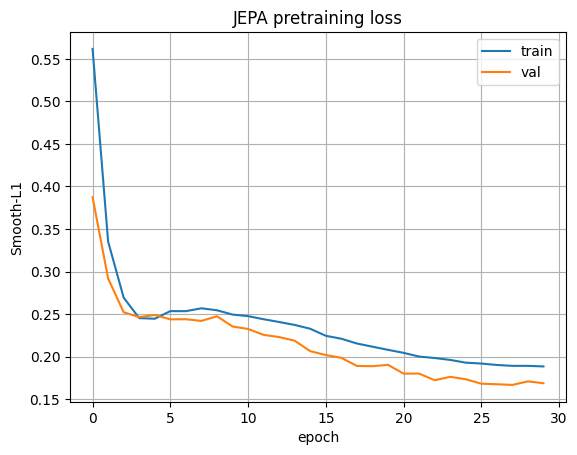

[done] notebook A finished - Save Version to keep OUT_DIR, then attach it to notebook B. ckpt=/kaggle/working/shop/jepa_best.pth


In [1]:
#!/usr/bin/env python3
"""SPACE-HOP notebook A — JEPA pretraining on SPEED (paste into ONE Kaggle cell, Run).

Paper: SPACE-HOP: Spacecraft 6-DoF Pose Estimation using Embedding-Predictive
Pretraining and Hopf Map (CVPR 2026 submission #36, confidential review copy).

What this file implements (paper Sec. -> code):
  Sec 3.1 (Eq.2-5)  keypoint-anchored masks, context/target encoders + EMA,
                    predictor ViT, Smooth-L1 in latent space (JEPA pretraining)

Scope deltas vs paper (SPEED-only, Kaggle-friendly):
  - Paper trains on SPEED+ synthetic (59,960 imgs). Here: SPEED trainval split
    (same 80/20 seed-42 protocol as fastpose/fastpose.ipynb).
  - Paper trains ViT from scratch. Default here: ImageNet init (torchvision
    ViT-B/16) for Kaggle-time convergence; set INIT = "random" for paper-faithful.

KAGGLE CELL HOW-TO (paste this ENTIRE file into ONE notebook cell, then Run):
  Notebook A (this file): add datasets speedsplit + mat-file, GPU on, Run.
    Verifies on SUBSET=300 first, then set SUBSET=None for the full run.
  When done: notebook output "Save Version" (or download) to keep jepa_best.pth,
    then attach it as input to notebook B (spacehop_b_finetune.py).
  9h cap: every epoch writes jepa_last.pth (model+optimizer+scheduler+epoch, like
    fastpose's checkpoint.pth) plus jepa_best.pth. To continue: attach the previous
    OUT_DIR as input (or keep the same notebook/output) and set RESUME="auto".
  Checkpoints/logs land in OUT_DIR (/kaggle/working/shop).

Outputs in OUT_DIR: jepa_best.pth, jepa_last.pth, jepa_log.csv.
"""
from __future__ import annotations

from types import SimpleNamespace
import copy
import json
import math
import os
import random
import time

import numpy as np

try:
    import torch
    import torch.nn.functional as F
    from torch import nn
    from torch.utils.data import DataLoader, Dataset
    from torchvision import models, transforms
except ImportError as e:
    raise SystemExit(f"torch/torchvision required: {e}")

try:
    from PIL import Image, ImageOps
except ImportError as e:
    raise SystemExit(f"pillow required: {e}")

try:
    from scipy.io import loadmat
except ImportError:  # keypoints .mat loading needs scipy; fall back to .txt
    loadmat = None

try:
    import albumentations as A
    _HAS_ALB = True
except ImportError:
    _HAS_ALB = False

EPS = 1e-8

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# ----------------------------------------------------------------------------
# *** EDIT ME *** — settings (plain variables, like fastpose.ipynb)
# ----------------------------------------------------------------------------
OUT_DIR = "/kaggle/working/shop"
EPOCHS = 30
BATCH_SIZE = 64
SUBSET = None  # None = full 9600; set 100-300 first to verify the run, like your other notebooks
LR = 1e-4
INIT = "imagenet"  # or "random" for paper-faithful from-scratch (slower)
IMG_SIZE = 224
WORKERS = 2
SEED = 42
PRED_DEPTH = 6
TGT_BLOCKS = 4
TGT_H = 4
TGT_W = 4
# optional path overrides (None = auto-detect mounted Kaggle datasets):
IMAGES_DIR = None
TRAIN_JSON = None
MAT_FILE = None
CAMERA_JSON = None
RESUME = None  # beat the ~9h cap: None | "auto" (OUT_DIR/jepa_last.pth) | explicit path

# ----------------------------------------------------------------------------
# Config / paths
# ----------------------------------------------------------------------------

KAGGLE_IMG_CANDIDATES = [
    "/kaggle/input/speedsplit/speed/images/trainval",
    "/kaggle/input/speed/speed/images/train",
]
KAGGLE_JSON_CANDIDATES = [
    "/kaggle/input/speedsplit/speed/train.json",
    "/kaggle/input/speed/speed/train.json",
]
KAGGLE_MAT = "/kaggle/input/mat-file/tangoPoints.mat"
KAGGLE_CAM = "/kaggle/input/mat-file/camera.json"
LOCAL_DEFAULTS = ("data/speed/images/train", "data/speed/labels/train.json",
                  "data/speed/tango_points.mat", "data/speed/camera.json")


def _discover_kaggle(root="/kaggle/input"):
    """Find SPEED files by walking mounted inputs (slug/layout agnostic).

    Dataset slugs vary (e.g. 'SPEEDsplit' vs 'speedsplit') and subfolders may
    differ, so instead of guessing absolute paths we search for:
      train.json, camera.json, *tango*.mat, and the jpg-heaviest train dir.
    """
    out = {"train_json": None, "images": None, "mat": None, "cam": None}
    if not os.path.isdir(root):
        return out
    best = (0, None)
    for dp, _dn, fn in os.walk(root):
        for f in fn:
            fl = f.lower()
            p = os.path.join(dp, f)
            if fl == "train.json" and out["train_json"] is None:
                out["train_json"] = p
            elif fl == "camera.json" and out["cam"] is None:
                out["cam"] = p
            elif fl.endswith(".mat") and "tango" in fl and out["mat"] is None:
                out["mat"] = p
        n_jpg = sum(1 for f in fn if f.lower().endswith((".jpg", ".jpeg", ".png")))
        low = dp.lower()
        if n_jpg > best[0] and ("train" in low or "image" in low):
            best = (n_jpg, dp)
    if out["mat"] is None:  # fallback: any .mat
        for dp, _dn, fn in os.walk(root):
            for f in fn:
                if f.lower().endswith(".mat"):
                    out["mat"] = os.path.join(dp, f)
                    break
            if out["mat"] is not None:
                break
    out["images"] = best[1]
    return out


def resolve_data(args):
    """Explicit path overrides first, then discovered Kaggle paths, then guesses."""
    disc = _discover_kaggle()

    def pick(explicit, discovered, cands, local):
        if explicit and os.path.exists(explicit):
            return explicit
        if discovered and os.path.exists(discovered):
            return discovered
        for c in cands:
            if c and os.path.exists(c):
                return c
        return local

    images = pick(args.images_dir, disc["images"], KAGGLE_IMG_CANDIDATES, LOCAL_DEFAULTS[0])
    js = pick(args.train_json, disc["train_json"], KAGGLE_JSON_CANDIDATES, LOCAL_DEFAULTS[1])
    mat = pick(args.mat_file, disc["mat"], [KAGGLE_MAT], LOCAL_DEFAULTS[2])
    cam = pick(args.camera_json, disc["cam"], [KAGGLE_CAM], LOCAL_DEFAULTS[3])
    return images, js, mat, cam


def _require_inputs(images, js):
    """Fail fast with a map of /kaggle/input when required files are missing."""
    for label, p in [("images", images), ("json", js)]:
        print(f"[setup] {label}: {p} {'OK' if os.path.exists(p) else 'MISSING'}", flush=True)
    missing = [p for p in (images, js) if not os.path.exists(p)]
    if missing:
        print("[setup] /kaggle/input map (top levels):")
        for dp, dn, fn in os.walk("/kaggle/input"):
            depth = dp.replace("/kaggle/input", "").count(os.sep)
            if depth > 2:
                dn[:] = []
                continue
            print(f"  {dp}: dirs={dn[:10]} files={fn[:10]}")
            if depth >= 2:
                dn[:] = []
        raise SystemExit(f"missing required inputs: {missing}")


def _resolve_resume(resume, out_dir, name):
    """None | "auto" (OUT_DIR/name) | explicit path -> existing ckpt path or None."""
    if resume is None:
        return None
    if resume == "auto":
        p = os.path.join(out_dir, name)
        return p if os.path.exists(p) else None
    return resume if os.path.exists(resume) else None


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


# ----------------------------------------------------------------------------
# Geometry: quaternions (scalar-first, SPEED convention) for projection
# ----------------------------------------------------------------------------

def quat2dcm_np(q):
    """Direction cosine matrix from scalar-first quaternion (numpy, for projection)."""
    q = np.asarray(q, dtype=np.float64)
    q = q / (np.linalg.norm(q) + 1e-12)
    w, x, y, z = q
    return np.array([
        [1 - 2 * (y * y + z * z), 2 * (x * y - z * w), 2 * (x * z + y * w)],
        [2 * (x * y + z * w), 1 - 2 * (x * x + z * z), 2 * (y * z - x * w)],
        [2 * (x * z - y * w), 2 * (y * z + x * w), 1 - 2 * (x * x + y * y)],
    ], dtype=np.float64)


def project_keypoints_np(q, t, camera_matrix, dist_coeffs, keypoints3d):
    """Project 11x3 body points to 2xN pixels (Brown distortion, cf. fastpose)."""
    kp = np.asarray(keypoints3d, dtype=np.float64)
    if kp.shape[0] != 3 and kp.shape[1] == 3:
        kp = kp.T  # -> 3xN
    kp_h = np.vstack([kp, np.ones((1, kp.shape[1]))])
    pose = np.hstack([quat2dcm_np(q).T, np.asarray(t, dtype=np.float64).reshape(3, 1)])
    xyz = pose @ kp_h
    x0, y0 = xyz[0] / xyz[2], xyz[1] / xyz[2]
    dc = np.asarray(dist_coeffs, dtype=np.float64).reshape(-1)
    k1, k2, p1, p2, k3 = (list(dc) + [0] * 5)[:5]
    r2 = x0 * x0 + y0 * y0
    cdist = 1 + k1 * r2 + k2 * r2 * r2 + k3 * r2 * r2 * r2
    x = x0 * cdist + p1 * 2 * x0 * y0 + p2 * (r2 + 2 * x0 * x0)
    y = y0 * cdist + p1 * (r2 + 2 * y0 * y0) + p2 * 2 * x0 * y0
    cm = np.asarray(camera_matrix, dtype=np.float64)
    return np.vstack([cm[0, 0] * x + cm[0, 2], cm[1, 1] * y + cm[1, 2]])


def quaternion_to_rotation_matrix(q: torch.Tensor) -> torch.Tensor:
    """Scalar-first quaternions (B,4) -> rotation matrices (B,3,3)."""
    r, i, j, k = torch.unbind(q, -1)
    two_s = 2.0 / (q * q).sum(-1).clamp_min(EPS)
    o = torch.stack([
        1 - two_s * (j * j + k * k), two_s * (i * j - k * r), two_s * (i * k + j * r),
        two_s * (i * j + k * r), 1 - two_s * (i * i + k * k), two_s * (j * k - i * r),
        two_s * (i * k - j * r), two_s * (j * k + i * r), 1 - two_s * (i * i + j * j),
    ], -1)
    return o.reshape(q.shape[:-1] + (3, 3))


def rotation_matrix_to_quaternion(R: torch.Tensor) -> torch.Tensor:
    """Rotation matrices (B,3,3) -> scalar-first quaternions (B,4), Shepperd branches."""
    m = R.reshape(-1, 3, 3)
    m00, m01, m02 = m[:, 0, 0], m[:, 0, 1], m[:, 0, 2]
    m10, m11, m12 = m[:, 1, 0], m[:, 1, 1], m[:, 1, 2]
    m20, m21, m22 = m[:, 2, 0], m[:, 2, 1], m[:, 2, 2]
    trace = m00 + m11 + m22
    q = torch.zeros((m.shape[0], 4), dtype=R.dtype, device=R.device)
    c0 = trace > 0
    if c0.any():
        s = torch.sqrt(trace[c0] + 1.0) * 2
        q[c0] = torch.stack([0.25 * s, (m21[c0] - m12[c0]) / s,
                             (m02[c0] - m20[c0]) / s, (m10[c0] - m01[c0]) / s], 1)
    c1 = (~c0) & (m00 > m11) & (m00 > m22)
    if c1.any():
        s = torch.sqrt(1.0 + m00[c1] - m11[c1] - m22[c1]) * 2
        q[c1] = torch.stack([(m21[c1] - m12[c1]) / s, 0.25 * s,
                             (m01[c1] + m10[c1]) / s, (m02[c1] + m20[c1]) / s], 1)
    c2 = (~c0) & (~c1) & (m11 > m22)
    if c2.any():
        s = torch.sqrt(1.0 + m11[c2] - m00[c2] - m22[c2]) * 2
        q[c2] = torch.stack([(m02[c2] - m20[c2]) / s, (m01[c2] + m10[c2]) / s,
                             0.25 * s, (m12[c2] + m21[c2]) / s], 1)
    c3 = (~c0) & (~c1) & (~c2)
    if c3.any():
        s = torch.sqrt(1.0 + m22[c3] - m00[c3] - m11[c3]) * 2
        q[c3] = torch.stack([(m10[c3] - m01[c3]) / s, (m02[c3] + m20[c3]) / s,
                             (m12[c3] + m21[c3]) / s, 0.25 * s], 1)
    return q.reshape(R.shape[:-2] + (4,))


# (SO(3) Hopf grid, Lie offsets and anchor lookup live in notebook B.)


# ----------------------------------------------------------------------------
# Camera + translation normalization (paper Sec 3.3; convention = fastpose.ipynb)
# ----------------------------------------------------------------------------

class Camera:
    """SPEED camera (UrsoNet values, verified vs SPEED paper)."""
    fwx = 0.0176
    fwy = 0.0176
    width = 1920
    height = 1200
    ppx = 5.86e-6
    ppy = ppx
    fx = fwx / ppx
    fy = fwy / ppy
    cx = width / 2
    cy = height / 2
    aspect_ratio = width / height


def translation_to_relative(t: torch.Tensor, bbox: torch.Tensor) -> torch.Tensor:
    """Absolute T (B,3) -> scale-invariant u=[Ux,Uy,Uz] (paper Eq.9/10 + CDPN)."""
    w = (bbox[:, 2] - bbox[:, 0]).clamp_min(1.0)
    h = (bbox[:, 3] - bbox[:, 1]).clamp_min(1.0)
    bx = bbox[:, 0] + (bbox[:, 2] - bbox[:, 0]) * 0.5
    by = bbox[:, 1] + (bbox[:, 3] - bbox[:, 1]) * 0.5
    tx, ty, tz = t[:, 0], t[:, 1], t[:, 2]
    avg = 0.5 * ((w * Camera.aspect_ratio) / Camera.width + h / Camera.height)
    Uz = tz * avg
    Ux = (tx * Camera.fx / tz + Camera.cx - bx) / w
    Uy = (ty * Camera.fy / tz + Camera.cy - by) / h
    return torch.stack([Ux, Uy, Uz], 1)
# ----------------------------------------------------------------------------
# Data
# ----------------------------------------------------------------------------

def load_tango_3d(mat_path):
    """11x3 body keypoints (.mat key 'tango3Dpoints', fallback .txt)."""
    if mat_path.endswith(".mat") and loadmat is not None and os.path.exists(mat_path):
        v = loadmat(mat_path)["tango3Dpoints"]
        return np.transpose(np.asarray(v, dtype=np.float32))  # 11x3
    txt = mat_path.replace(".mat", ".txt")
    if os.path.exists(txt):
        return np.loadtxt(txt, dtype=np.float32).reshape(-1, 3)
    print(f"[warn] keypoints not found ({mat_path}); using zeros (masking degrades to random).")
    return np.zeros((11, 3), dtype=np.float32)


def load_camera(json_path):
    if os.path.exists(json_path):
        with open(json_path) as f:
            cam = json.load(f)
        return (np.array(cam["cameraMatrix"], dtype=np.float64),
                np.array(cam["distCoeffs"], dtype=np.float64))
    print(f"[warn] camera json not found ({json_path}); using defaults.")
    K = np.array([[Camera.fx, 0, Camera.cx], [0, Camera.fy, Camera.cy], [0, 0, 1]])
    return K, np.zeros(5)


class SpeedHop(Dataset):
    """SPEED crop dataset: 224px crops + U targets + R_gt + crop-frame keypoints.

    Bboxes are derived from projected GT keypoints (+15% margin, squared), same
    recipe as fastpose.ipynb _get_bbox_from_keypoints (GT boxes; no detector).
    """

    def __init__(self, images_dir, json_path, mat_path, cam_path, img_size=224,
                 augment=False, transform=None):
        self.images_dir = images_dir
        self.img_size = img_size
        self.augment = augment
        self.transform = transform
        with open(json_path) as f:
            annotations = json.load(f)
        lookup = {a["filename"]: a for a in annotations}
        files = sorted(os.listdir(images_dir)) if os.path.isdir(images_dir) else []
        self.items, self.boxes, self.qs, self.ts = [], [], [], []
        self.k3d = load_tango_3d(mat_path)
        self.cam_mat, self.dist = load_camera(cam_path)
        for fn in files:
            if fn not in lookup:
                continue
            a = lookup[fn]
            q = np.array(a["q_vbs2tango"], dtype=np.float32)
            t = np.array(a["r_Vo2To_vbs_true"], dtype=np.float32)
            k2d = project_keypoints_np(q, t, self.cam_mat, self.dist, self.k3d)
            self.items.append(os.path.join(images_dir, fn))
            self.boxes.append(self._bbox(k2d))
            self.qs.append(q)
            self.ts.append(t)
        print(f"[data] {json_path}: {len(self.items)} images")
        if _HAS_ALB and augment:
            self.pixel_aug = A.Compose([
                A.OneOf([A.RandomBrightnessContrast(p=1.0),
                         A.HueSaturationValue(p=1.0), A.RGBShift(p=1.0)], p=0.5),
                A.OneOf([A.MotionBlur(p=1.0), A.GaussianBlur(p=1.0),
                         A.GaussNoise(p=1.0)], p=0.5),
            ], p=1.0)
        else:
            self.pixel_aug = None

    @staticmethod
    def _bbox(k2d):
        xmin, xmax = float(k2d[0].min()), float(k2d[0].max())
        ymin, ymax = float(k2d[1].min()), float(k2d[1].max())
        xmin -= (xmax - xmin) * 0.075; xmax += (xmax - xmin) * 0.075
        ymin -= (ymax - ymin) * 0.075; ymax += (ymax - ymin) * 0.075
        cx, cy = (xmin + xmax) / 2, (ymin + ymax) / 2
        s = max(xmax - xmin, ymax - ymin)
        return torch.tensor([cx - s / 2, cy - s / 2, cx + s / 2, cy + s / 2])

    def _safe_crop(self, img, bbox):
        xmin, ymin, xmax, ymax = (bbox.tolist() if torch.is_tensor(bbox) else bbox)
        pl = max(0, math.ceil(-xmin)); pt = max(0, math.ceil(-ymin))
        pr = max(0, math.ceil(xmax - img.width)); pb = max(0, math.ceil(ymax - img.height))
        if pl or pt or pr or pb:
            img = ImageOps.expand(img, border=(pl, pt, pr, pb), fill=0)
        return img.crop((int(xmin + pl), int(ymin + pt), int(xmax + pl), int(ymax + pt)))

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        img = Image.open(self.items[idx]).convert("RGB")
        bbox, q, t = self.boxes[idx].clone(), self.qs[idx].copy(), self.ts[idx].copy()
        if self.augment:  # light in-plane rotation, cf. fastpose _augment_spatial
            if np.random.rand() > 0.5:
                deg = (np.random.uniform(-20, 20) if np.random.rand() < 0.5
                       else np.random.uniform(160, 200))
                r = np.deg2rad(deg); c, s = np.cos(r), np.sin(r)
                Rz = np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])
                R = Rz @ quat2dcm_np(q)
                # back to quat (scalar-first) via torch helper on numpy
                q = rotation_matrix_to_quaternion(
                    torch.from_numpy(R).float().unsqueeze(0)).squeeze(0).numpy()
                t = (Rz @ t).astype(np.float32)
                img = img.rotate(-deg, resample=Image.BILINEAR)
                k2d = project_keypoints_np(q, t, self.cam_mat, self.dist, self.k3d)
                bbox = self._bbox(k2d)
        crop = self._safe_crop(img, bbox.tolist()).resize(
            (self.img_size, self.img_size), Image.BILINEAR)
        if self.augment and self.pixel_aug is not None:
            crop = Image.fromarray(self.pixel_aug(image=np.array(crop))["image"])
        xmin, ymin, xmax, ymax = bbox.tolist()
        bw, bh = max(xmax - xmin, 1e-3), max(ymax - ymin, 1e-3)
        k2d = project_keypoints_np(q, t, self.cam_mat, self.dist, self.k3d)
        kc = np.stack([(k2d[0] - xmin) / bw * self.img_size,
                       (k2d[1] - ymin) / bh * self.img_size], 1).astype(np.float32)
        if self.transform:
            crop = self.transform(crop)
        qt = torch.from_numpy(q).float()
        tt = torch.from_numpy(t).float()
        u = translation_to_relative(tt.unsqueeze(0), bbox.unsqueeze(0)).squeeze(0)
        R = quaternion_to_rotation_matrix(qt.unsqueeze(0)).squeeze(0)
        return {"image": crop, "u": u, "R": R, "q": qt, "t": tt,
                "bbox": bbox, "kpts": torch.from_numpy(kc)}


# ----------------------------------------------------------------------------
# Keypoint-anchored masking (paper Eq.2-3)
# ----------------------------------------------------------------------------

def sample_target_blocks(kpts_px, img_size=224, patch=16, n_blocks=4,
                         bh=4, bw=4, rng=None):
    """Target patch ids clustered around projected keypoints; returns LongTensor.

    For keypoint (xn,yn): ytop ~ U(max(0,[yn/p]-h), min(G-h,[yn/p]+1)) (Eq.2-3).
    Falls back to uniform blocks when all keypoints lie outside the crop.
    """
    rng = rng or random
    G = img_size // patch
    ids: set[int] = set()
    kpts = np.asarray(kpts_px).reshape(-1, 2)
    for _ in range(n_blocks):
        inside = [k for k in kpts if 0 <= k[0] < img_size and 0 <= k[1] < img_size]
        if inside:
            xn, yn = inside[rng.randrange(len(inside))]
            xk, yk = int(xn // patch), int(yn // patch)
            lo_y, hi_y = max(0, yk - bh), min(G - bh, yk + 1)
            lo_x, hi_x = max(0, xk - bw), min(G - bw, xk + 1)
            if hi_y < lo_y:
                lo_y = hi_y = max(0, min(G - bh, yk))
            if hi_x < lo_x:
                lo_x = hi_x = max(0, min(G - bw, xk))
            yt = rng.randint(lo_y, hi_y)
            xl = rng.randint(lo_x, hi_x)
        else:
            yt = rng.randint(0, max(0, G - bh)); xl = rng.randint(0, max(0, G - bw))
        for dy in range(bh):
            for dx in range(bw):
                ids.add((yt + dy) * G + (xl + dx))
    return torch.tensor(sorted(ids), dtype=torch.long)


# ----------------------------------------------------------------------------
# Models: subset-able ViT encoder (reuses torchvision weights) + predictor
# ----------------------------------------------------------------------------

def _vit_parts(vit):
    """Resolve (conv, cls, pos, dropout, layers, ln, dim) across torchvision versions."""
    conv = getattr(vit, "conv_proj", None)
    cls = getattr(vit, "class_token", None)
    enc = getattr(vit, "encoder", vit)
    pos = getattr(enc, "pos_embedding", getattr(vit, "pos_embedding",
                 getattr(enc, "pos_embed", getattr(vit, "pos_embed", None))))
    drop = getattr(enc, "dropout", nn.Dropout(0.1))
    layers = getattr(enc, "layers", None)
    ln = getattr(enc, "ln", getattr(enc, "norm", None))
    dim = getattr(vit, "hidden_dim", 768)
    if conv is None or cls is None or pos is None or layers is None or ln is None:
        raise RuntimeError("Unsupported torchvision ViT layout; "
                           f"got conv={conv is not None} cls={cls is not None} "
                           f"pos={pos is not None} layers={layers is not None} ln={ln is not None}")
    return conv, cls, pos, drop, layers, ln, dim


def build_template_vit(init="imagenet"):
    if init == "imagenet":
        try:
            w = models.ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1
        except AttributeError:
            w = models.ViT_B_16_Weights.DEFAULT
        try:
            return models.vit_b_16(weights=w)
        except Exception as e:
            print(f"[warn] pretrained load failed ({e}); using DEFAULT.")
            return models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
    return models.vit_b_16(weights=None)


class PatchViT(nn.Module):
    """ViT-B/16 encoder with patch-subset forward (independent params via deepcopy)."""

    def __init__(self, init="imagenet", img_size=224):
        super().__init__()
        vit = build_template_vit(init)
        conv, cls, pos, drop, layers, ln, dim = _vit_parts(vit)
        self.conv_proj = copy.deepcopy(conv)
        self.cls_token = nn.Parameter(cls.detach().clone())
        self.pos_embed = nn.Parameter(self._interp_pos(pos.detach().clone(), dim, img_size))
        self.dropout = copy.deepcopy(drop)
        self.layers = copy.deepcopy(layers)
        self.ln = copy.deepcopy(ln)
        self.dim = dim
        self.n_patches = (img_size // 16) ** 2  # 196 @224

    @staticmethod
    def _interp_pos(pos, dim, img_size):
        """Resize pretrained pos-embed grid to the training resolution.

        SWAG ViT-B/16 ships a 384px grid (576+1 slots); at 224px we need
        196+1. Bicubic-interpolate the patch grid, keep CLS as-is.
        """
        G = img_size // 16
        n0 = pos.size(1) - 1
        if n0 == G * G:
            return pos
        g0 = int(round(n0 ** 0.5))
        if g0 * g0 != n0:  # non-square grid: truncate/pad fallback
            grid = pos[:, 1:, :].repeat(1, (G * G) // n0 + 1, 1)[:, :G * G, :]
            return torch.cat([pos[:, :1, :], grid], 1)
        patch = pos[:, 1:, :].reshape(1, g0, g0, dim).permute(0, 3, 1, 2)
        patch = F.interpolate(patch, size=(G, G), mode="bicubic", align_corners=False)
        patch = patch.permute(0, 2, 3, 1).reshape(1, G * G, dim)
        return torch.cat([pos[:, :1, :], patch], 1)

    def patchify(self, x):
        return self.conv_proj(x).flatten(2).transpose(1, 2)  # B,N,D

    def forward_keep(self, x, keep=None):
        tok = self.patchify(x)
        if keep is not None:
            tok = tok[:, keep, :]
            pos = torch.cat([self.pos_embed[:, :1, :],
                             self.pos_embed[:, 1:, :][:, keep, :]], 1)
        else:
            pos = self.pos_embed
        seq = torch.cat([self.cls_token.expand(x.size(0), -1, -1), tok], 1) + pos
        seq = self.dropout(seq)
        for blk in self.layers:
            seq = blk(seq)
        return self.ln(seq)  # B,1+C,D (CLS first)


class Predictor(nn.Module):
    """Lightweight transformer: context tokens + mask tokens -> target embeddings."""

    def __init__(self, dim=768, depth=6, n_heads=12, n_patches=196):
        super().__init__()
        self.mask_token = nn.Parameter(torch.zeros(1, 1, dim))
        nn.init.trunc_normal_(self.mask_token, std=0.02)
        self.pos = nn.Parameter(torch.zeros(1, n_patches, dim))
        nn.init.trunc_normal_(self.pos, std=0.02)
        layer = nn.TransformerEncoderLayer(d_model=dim, nhead=n_heads, dim_feedforward=dim * 4,
                                           dropout=0.1, activation="gelu",
                                           batch_first=True, norm_first=True)
        self.enc = nn.TransformerEncoder(layer, num_layers=depth)

    def forward(self, ctx_tok, ctx_idx, tgt_idx, n_patches):
        B, D = ctx_tok.size(0), ctx_tok.size(-1)
        canvas = self.mask_token.expand(B, n_patches, D).clone() + self.pos[:, :n_patches, :]
        canvas[torch.arange(B).unsqueeze(1), ctx_idx] = ctx_tok + self.pos[0, ctx_idx]
        return self.enc(canvas)[torch.arange(B).unsqueeze(1), tgt_idx]


# SpaceHOP heads + Stage B (finetune) live in notebook B (spacehop_b_finetune.py).


# ----------------------------------------------------------------------------
# Stage A: JEPA pretraining
# ----------------------------------------------------------------------------

def ema_update(ctx: PatchViT, tgt: PatchViT, m: float):
    with torch.no_grad():
        for pc, pt in zip(ctx.parameters(), tgt.parameters()):
            pt.mul_(m).add_(pc.detach(), alpha=1 - m)


# ----------------------------------------------------------------------------
# Curves (like fastpose.ipynb: loss plots saved to OUT_DIR and shown inline)
# ----------------------------------------------------------------------------

def _get_plt():
    try:
        import matplotlib.pyplot as plt
        return plt
    except ImportError:
        print("[plot] matplotlib missing, skipping curves")
        return None


def _plot_jepa(log, out_dir):
    plt = _get_plt()
    log = np.asarray(log, dtype=float)
    if plt is None or log.size == 0:
        return
    plt.figure()
    plt.plot(log[:, 0], label="train")
    if log.shape[1] > 1:
        plt.plot(log[:, 1], label="val")
    plt.xlabel("epoch"); plt.ylabel("Smooth-L1"); plt.legend(); plt.grid(True)
    plt.title("JEPA pretraining loss")
    plt.savefig(f"{out_dir}/jepa_curves.png", dpi=100)
    print(f"[plot] saved {out_dir}/jepa_curves.png")
    try:
        plt.show()
    except Exception:
        pass
    plt.close()


def train_jepa(train_ds, val_ds, args, device):
    G = args.img_size // 16
    ctx = PatchViT(args.init, args.img_size).to(device)
    tgt = PatchViT(args.init, args.img_size).to(device)
    tgt.load_state_dict(ctx.state_dict())
    for p in tgt.parameters():
        p.requires_grad_(False)
    pred = Predictor(ctx.dim, args.pred_depth, n_patches=G * G).to(device)
    opt = torch.optim.AdamW(list(ctx.parameters()) + list(pred.parameters()),
                            lr=args.lr, weight_decay=0.05)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, args.epochs)
    tl = DataLoader(train_ds, args.batch_size, shuffle=True, num_workers=args.workers,
                    pin_memory=device.type == "cuda", drop_last=True)
    vl = DataLoader(val_ds, min(args.batch_size, 64), shuffle=False, num_workers=args.workers,
                    pin_memory=device.type == "cuda")
    start_ep, best, log = 0, float("inf"), []
    rk = _resolve_resume(args.resume, args.out_dir, "jepa_last.pth")
    if rk:
        ck = torch.load(rk, map_location=device)
        ctx.load_state_dict(ck["context_encoder"])
        pred.load_state_dict(ck["predictor"])
        tgt.load_state_dict(ctx.state_dict())  # EMA history not stored; re-syncs within steps
        try:
            opt.load_state_dict(ck["optimizer"])
            sched.load_state_dict(ck["scheduler"])
        except Exception as e:
            print(f"[jepa] optimizer/scheduler state skipped ({e})")
        start_ep = int(ck.get("epoch", 0))
        best = float(ck.get("best", best))
        print(f"[jepa] resumed from {rk} at epoch {start_ep}")
    m0, m1 = 0.996, 1.0
    n_train = len(train_ds)
    for ep in range(start_ep, args.epochs):
        ctx.train(); pred.train()
        m = m0 + (m1 - m0) * ep / max(args.epochs - 1, 1)
        tot, n = 0.0, 0
        t0 = time.time()
        for bi, batch in enumerate(tl):
            x = batch["image"].to(device, non_blocking=True)
            B = x.size(0)
            opt.zero_grad()
            loss_acc = 0.0
            with torch.no_grad():
                full = tgt.forward_keep(x)[:, 1:, :]  # target embeddings
            for b in range(B):  # per-sample keypoint-anchored masks (paper-faithful)
                tb = sample_target_blocks(batch["kpts"][b].cpu().numpy(), args.img_size,
                                          16, args.tgt_blocks, args.tgt_h, args.tgt_w)
                keep_mask = torch.ones(G * G, dtype=torch.bool)
                keep_mask[tb] = False
                cb = keep_mask.nonzero().squeeze(1)
                if cb.numel() == 0 or tb.numel() == 0:
                    continue
                c = ctx.forward_keep(x[b:b + 1], cb.to(device))
                pr = pred(c[:, 1:, :], cb.to(device).unsqueeze(0),
                          tb.to(device).unsqueeze(0), G * G)
                loss_acc = loss_acc + F.smooth_l1_loss(pr, full[b:b + 1, tb.to(device), :])
            if isinstance(loss_acc, float):
                continue
            (loss_acc / B).backward()
            torch.nn.utils.clip_grad_norm_(list(ctx.parameters()) + list(pred.parameters()), 1.0)
            opt.step()
            ema_update(ctx, tgt, m)
            tot += float((loss_acc / B).detach().cpu()); n += 1
            cur = min((bi + 1) * tl.batch_size, n_train)
            print(f"\r[jepa] Epoch {ep + 1}/{args.epochs} : train {tot / n:.4f} [{cur:>5d}/{n_train:>5d}]",
                  end="", flush=True)
        ctx.eval(); pred.eval()
        with torch.no_grad():
            vtot, vn = 0.0, 0
            for batch in vl:
                x = batch["image"].to(device)
                full = tgt.forward_keep(x)[:, 1:, :]
                B = x.size(0)
                bl = 0.0
                for b in range(min(B, 8)):  # val subset for speed
                    tb = sample_target_blocks(batch["kpts"][b].cpu().numpy(), args.img_size,
                                              16, args.tgt_blocks, args.tgt_h, args.tgt_w)
                    keep_mask = torch.ones(G * G, dtype=torch.bool); keep_mask[tb] = False
                    cb = keep_mask.nonzero().squeeze(1)
                    c = ctx.forward_keep(x[b:b + 1], cb.to(device))
                    pr = pred(c[:, 1:, :], cb.to(device).unsqueeze(0),
                              tb.to(device).unsqueeze(0), G * G)
                    bl = bl + float(F.smooth_l1_loss(pr, full[b:b + 1, tb.to(device), :]).detach().cpu())
                vtot += bl / min(B, 8); vn += 1
        sched.step()
        tr, va = tot / max(n, 1), vtot / max(vn, 1)
        log.append((tr, va))
        dt = time.time() - t0
        print(f"\r[jepa] Epoch {ep + 1}/{args.epochs} : train {tr:.4f} | val {va:.4f} "
              f"| ema {m:.5f} | {n_train}/{n_train} imgs | {dt / 60:.1f}min                    ",
              flush=True)
        torch.save({"context_encoder": ctx.state_dict(), "predictor": pred.state_dict(),
                    "optimizer": opt.state_dict(), "scheduler": sched.state_dict(),
                    "epoch": ep + 1, "best": best}, f"{args.out_dir}/jepa_last.pth")
        if va < best:
            best = va
            torch.save({"context_encoder": ctx.state_dict(), "predictor": pred.state_dict(),
                        "optimizer": opt.state_dict(), "scheduler": sched.state_dict(),
                        "epoch": ep + 1, "best": best}, f"{args.out_dir}/jepa_best.pth")
    np.savetxt(f"{args.out_dir}/jepa_log.csv", np.array(log), delimiter=",", header="train,val")
    _plot_jepa(log, args.out_dir)
    return f"{args.out_dir}/jepa_best.pth"


# -- Stage B (Hopf classify+refine, finetune, eval) lives in spacehop_b_finetune.py --
# This file is notebook A: JEPA pretraining only.


# ----------------------------------------------------------------------------
# Run — notebook A: JEPA pretraining, top to bottom (no stage switch).
# ----------------------------------------------------------------------------
print("[cell] SPACE-HOP notebook A : JEPA pretraining", flush=True)

set_seed(SEED)
os.makedirs(OUT_DIR, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# bundle the settings above for the helper functions (same values, one place)
args = SimpleNamespace(
    images_dir=IMAGES_DIR, train_json=TRAIN_JSON,
    mat_file=MAT_FILE, camera_json=CAMERA_JSON,
    out_dir=OUT_DIR, init=INIT, img_size=IMG_SIZE, epochs=EPOCHS,
    batch_size=BATCH_SIZE, lr=LR, workers=WORKERS,
    seed=SEED, pred_depth=PRED_DEPTH, tgt_blocks=TGT_BLOCKS,
    tgt_h=TGT_H, tgt_w=TGT_W, resume=RESUME,
)
print(f"[setup] device={device} stage=pretrain out={args.out_dir}")

images, js, mat, cam = resolve_data(args)
_require_inputs(images, js)
for _label, _p in [("mat", mat), ("cam", cam)]:
    print(f"[setup] {_label}: {_p} {'OK' if os.path.exists(_p) else 'MISSING (using fallback)'}",
          flush=True)
tf = transforms.Compose([transforms.ToTensor(),
                         transforms.Normalize([0.485, 0.456, 0.406],
                                              [0.229, 0.224, 0.225])])
full_train = SpeedHop(images, js, mat, cam, args.img_size, True, tf)
full_val = SpeedHop(images, js, mat, cam, args.img_size, False, tf)
n = len(full_train)
assert n > 0, "empty dataset - set IMAGES_DIR / TRAIN_JSON above"
idx = list(range(n))
random.Random(args.seed).shuffle(idx)
if SUBSET is not None:  # verify on 100-300 images first, like your other runs
    idx = idx[:max(10, int(SUBSET))]
s = int(0.8 * len(idx))
train_ds = torch.utils.data.Subset(full_train, idx[:s])
val_ds = torch.utils.data.Subset(full_val, idx[s:])
tag = " (SUBSET verify run - set SUBSET=None for full data)" if SUBSET is not None else ""
print(f"[setup] train={len(train_ds)} val={len(val_ds)}{tag}")

jepa_ckpt = train_jepa(train_ds, val_ds, args, device)
print(f"[done] notebook A finished - Save Version to keep OUT_DIR, then attach it to notebook B. ckpt={jepa_ckpt}")
